# 06c · GSE65391 · RNA_array · module scores in SLE against healthy children

Reads `projected_scores.rds` (notebook 05b).

**Samples.** The first visit of each child: 157 children with SLE and 46 healthy children (one sample
per child), all scored on the first-visit modules (notebook 05b).

**Test 1.** For each module: Wilcoxon rank-sum test of SLE against healthy scores; BH q across the 14
modules. Effect size: the difference in medians, in score units. **A finding** is q < 0.05.

**Comparison with Banchereau et al. 2016 (claim B5).** Against healthy controls, the paper reports
modules for erythropoiesis over-expressed and NK cell / cytotoxicity under-expressed in SLE (Fig. 1C).
Here: brown (red cell hub genes) and turquoise, which holds the NK / cytotoxic genes at this power
(notebook 05) together with other lymphoid genes, so it is not an NK-specific module.

**Test 2 (claim B1).** The paper reports an interferon signature in 84.8% of SLE samples (Fig. 1E),
using its own module definitions and a rule per sample (transcripts with fold change >= 1.5 and raw
difference >= 100 against the healthy median). Those module definitions are not part of this analysis,
so the paper's rule cannot be applied as written. **This test is ours, not the paper's:** the share of
SLE first visits whose interferon module (black) score lies above the 97.5th percentile of the healthy
children, the upper limit of the central 95% reference interval of the healthy scores. The comparison
with 84.8% is therefore approximate and is reported as such.

## Select one sample per child

In [1]:
source("../src/paths.R")
p <- readRDS(art("GSE65391", "projected_scores.rds"))
m <- p$meta; S <- p$scores
h <- m[m$disease == "Healthy", ]; h <- h[order(h$subject, h$visit), ]
healthy <- rownames(h)[!duplicated(h$subject)]
sle <- rownames(m)[m$disease == "SLE" & m$first_visit]
c(SLE_first_visits = length(sle), healthy_children = length(healthy))

SLE_first_visits healthy_children 
             157               46

**Explanation**
- `projected_scores.rds` (notebook 05b) holds every sample's module scores and the sample table.
- `h` holds the healthy samples, ordered by child and visit with `order(h$subject, h$visit)`.
- `!duplicated(h$subject)` is TRUE for the first sample of each healthy child, so `healthy` holds one sample
  per healthy child.
- `sle` holds the first visit of each child with SLE.

## Test 1: SLE against healthy, each module

In [2]:
res <- do.call(rbind, lapply(colnames(S), function(mo) {
  wt <- wilcox.test(S[sle, mo], S[healthy, mo])
  data.frame(module = mo, median_SLE = median(S[sle, mo]), median_healthy = median(S[healthy, mo]),
             difference = median(S[sle, mo]) - median(S[healthy, mo]), p = wt$p.value)
}))
res$q <- p.adjust(res$p, "BH")
res <- res[order(res$p), ]
format(res, digits = 3)

,module,median_SLE,median_healthy,difference,p,q
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
9,black,0.004528,-0.14511,0.1496,5.75e-18,8.04e-17
1,turquoise,0.003292,0.07869,-0.0754,1.15e-10,8.06e-10
2,cyan,-0.029731,-0.06387,0.0341,5.15e-10,2.40e-09
7,yellow,-0.011487,0.05987,-0.0714,8.01e-08,2.80e-07
3,blue,-0.004381,-0.06128,0.0569,9.93e-07,2.78e-06
6,brown,-0.011284,-0.04666,0.0354,6.06e-04,1.41e-03
5,salmon,0.004383,0.03492,-0.0305,3.01e-03,6.02e-03
13,greenyellow,-0.002549,-0.02820,0.0256,4.26e-03,7.46e-03
12,pink,-0.019426,-0.03623,0.0168,5.11e-02,7.95e-02


**Explanation**
- For each module `mo`:
  - `wilcox.test(x, y)` is the Wilcoxon rank-sum test of SLE scores against healthy scores (Wilcoxon F.
    *Biometrics Bull* 1945;1:80-83). It compares ranks, so it does not assume normal scores.
  - `data.frame(...)` makes one row: the two medians, their difference and the p value.
- `do.call(rbind, ...)` stacks the 14 rows; `p.adjust(res$p, "BH")` adds Benjamini-Hochberg q values (see
  notebook 06b); `order(res$p)` sorts from the smallest p.

**Result.** 8 of 14 modules differ between SLE and healthy children at q < 0.05. The largest differences:
black (interferon, higher in SLE, q = 8e-17), turquoise (lower in SLE), cyan (neutrophil granule, higher) and
yellow (ribosomal, lower).

**Comparison with claim B5.**

In [3]:
res[res$module %in% c("brown", "turquoise"), ]   # brown: red cell; turquoise holds the NK / cytotoxic genes (notebook 05)

,module,median_SLE,median_healthy,difference,p,q
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,turquoise,0.003292273,0.07869029,-0.07539802,1.151041e-10,8.057285e-10
6,brown,-0.011283895,-0.04666467,0.03538078,6.057551e-04,1.413429e-03


**Explanation**
- `%in%` keeps the rows of the red-cell module (brown) and turquoise, which holds the NK / cytotoxic genes; the two
  modules that correspond to the paper's Figure 1C.

**Result: claim B5 partly reproduced.** The red-cell module (brown) is higher in SLE (q = 0.001), as in the
paper's Fig. 1C. At this power there is no separate NK / cytotoxic module; turquoise, which holds those genes
together with other lymphoid genes, is lower in SLE (q = 8e-10), the paper's direction, but it is not specific
to NK cells.

**Test 2.** Share of SLE first visits above the healthy 97.5th percentile of the interferon (black) score.

In [4]:
limit <- quantile(S[healthy, "black"], 0.975)      # black: the interferon module (notebook 05)
c(healthy_97.5th_percentile = round(unname(limit), 4),
  SLE_above = sum(S[sle, "black"] > limit), SLE_first_visits = length(sle),
  percent_above = round(100 * mean(S[sle, "black"] > limit), 1))

healthy_97.5th_percentile                 SLE_above          SLE_first_visits 
                  -0.0315                  111.0000                  157.0000 
            percent_above 
                  70.7000

**Explanation**
- `quantile(x, 0.975)` gives the value below which 97.5% of the healthy children's interferon scores lie.
- `sum(S[sle, "black"] > limit)` counts the SLE first visits above it; `mean(...)` gives the share, and
  `100 *` turns it into a percentage.
- `unname()` drops the label "97.5%" that `quantile()` attaches.

**Result: claim B1, approximate.** 70.7% of SLE first visits (111 of 157) lie above the healthy
97.5th percentile of the interferon module. The paper reports 84.8% with its own rule and module
definitions; the two numbers are not directly comparable, and both show an interferon signature in
most children with SLE.

## Plot the scores by group

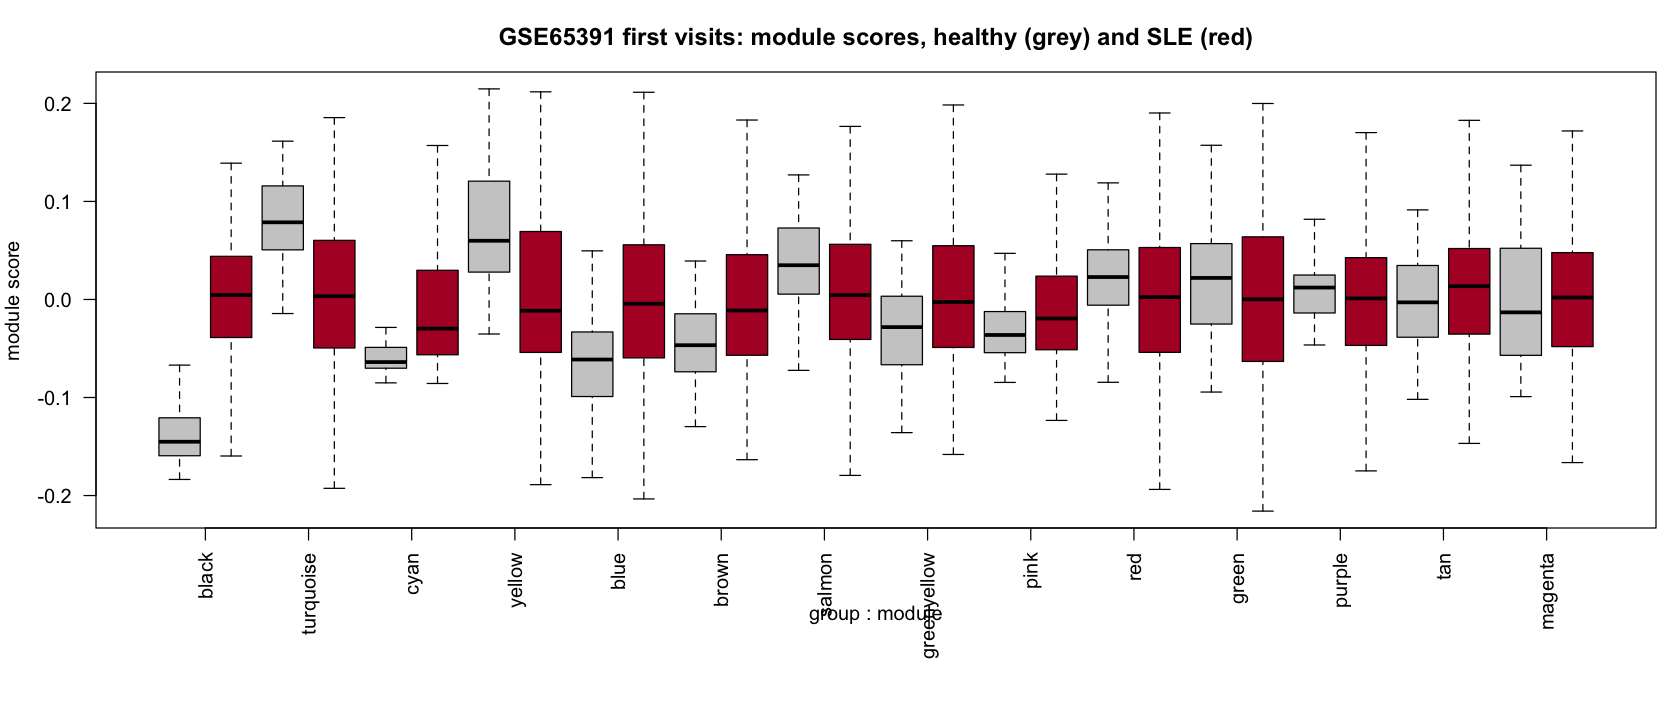

In [5]:
options(repr.plot.width = 14, repr.plot.height = 6)
figure <- function() {
  ord <- res$module
  long <- data.frame(module = factor(rep(ord, each = length(c(healthy, sle))), levels = ord),
                     group = rep(c(rep("healthy", length(healthy)), rep("SLE", length(sle))), length(ord)),
                     score = as.vector(sapply(ord, function(mo) c(S[healthy, mo], S[sle, mo]))))
  par(mar = c(8, 4, 3, 1))
  boxplot(score ~ group + module, data = long, las = 2, col = c("grey80", "#B2182B"), outline = FALSE,
          names = rep("", 2 * length(ord)), ylab = "module score", xaxt = "n",
          main = "GSE65391 first visits: module scores, healthy (grey) and SLE (red)")
  axis(1, at = seq(1.5, 2 * length(ord), by = 2), labels = ord, las = 2)
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "06c_GSE65391_RNA_array_sle_vs_healthy_1.png"), width = 14, height = 6, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `long` rearranges the scores into one row per sample and module, with columns `module`, `group` and
  `score`, the layout `boxplot()` needs. `rep(x, each = n)` repeats each value n times; `rep(x, n)` repeats
  the whole vector n times.
- `boxplot(score ~ group + module, ...)` draws one box per group and module, modules in the order of the
  test results. `outline = FALSE` hides single outlying points.
- `axis(1, at = ..., labels = ord, las = 2)` writes each module name under its pair of boxes, turned
  vertical.
- The figure loop is explained in notebook 04.